# Simple Exponential Smoothing


## Prerequisites:

To learn Simple Exponential Smoothing (SES) model, you need to have proper understanding of a few basic concepts like:

- Time Series data
- Time Series Terminologies


## Learning Objective:

- Understand the concept of Exponential Smoothing.
- Understand the idea of Simple Exponential Smoothing, its mathematical expression.
- Analyze the effects of $\alpha$ in weights.


## 1. Introduction to Exponential Smoothing

We've learned about the mean method, whose forecasts are equal to the observed data's mean. The mean method weights each past values equally. But as we discussed on AR models, the general tendency is that the values for any timestamp are more likely dependent on the immediate past values than on the values far away. Thus, a weighted technique that weights more on the recent values and less on the older values can model the time series.  Exponential smoothing appears in the scene. Exponential Smoothing (ES) methods use exponential decaying weights for past values. For a time series $X = 
\{ X_t = x_t \}_{t=0} ^T$, the ES method forecast at timestamp $T + 1$ is given as:

$$\hat{X}_{T + 1} = \alpha [ x_T + (1-\alpha) x_{T-1} + (1-\alpha)^2 x_{T-2} + (1-\alpha)^3 x_{T-3} + ...].$$

Here, $\alpha$ is some parameter such that $0 < \alpha < 1$. 
The weights for $x_T, x_{T-1}, x_{T-2}, x_{T-3},...$ are equal to $\alpha, \alpha (1 - \alpha), \alpha (1 - \alpha)^2, \alpha (1 - \alpha)^3, ...$. Thus at any timestamp, h timestamps before T, the weight ES puts on the value $x_{T-h}$ is $\alpha (1 - \alpha)^h$. And with $0 < \alpha < 1$ as the constraint, the weights on the older values are lesser than on the immediate past values. Figure 1 shows the weights an ES method, with  $\alpha = 0.2$, would assign for timestamps earlier than the forecasting timestamp, shown by the magenta vertical line.         

<center>


<p>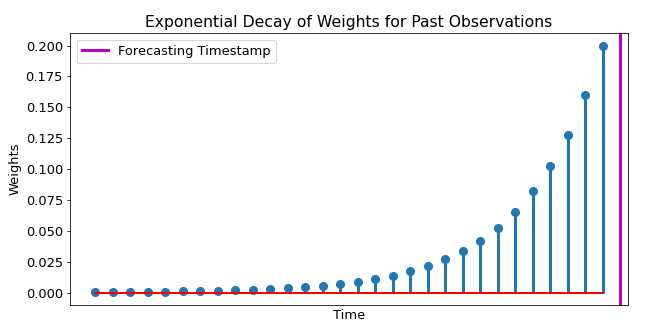</p>

Figure 1: Weights for Past Observations 
</center>


You'll study about three exponential smoothing methods in this unit, namely: Simple Exponential Smoothing, Holt's Exponential Smoothing, and Holt-Winters' Exponential Smoothing. Given some data, figure 2 depicts the way we usually follow to select a method to fit the data. If the data is stationary or has neither trend nor seasonality, we can use a simple exponential smoothing method. You'll learn about this method in this chapter. If the data contains trend but not seasonality, we can fit Holt's exponential smoothing method on the data. And if seasonality is present on the data, we resort to Holt-Winters' exponential smoothing.   

<center>


<p>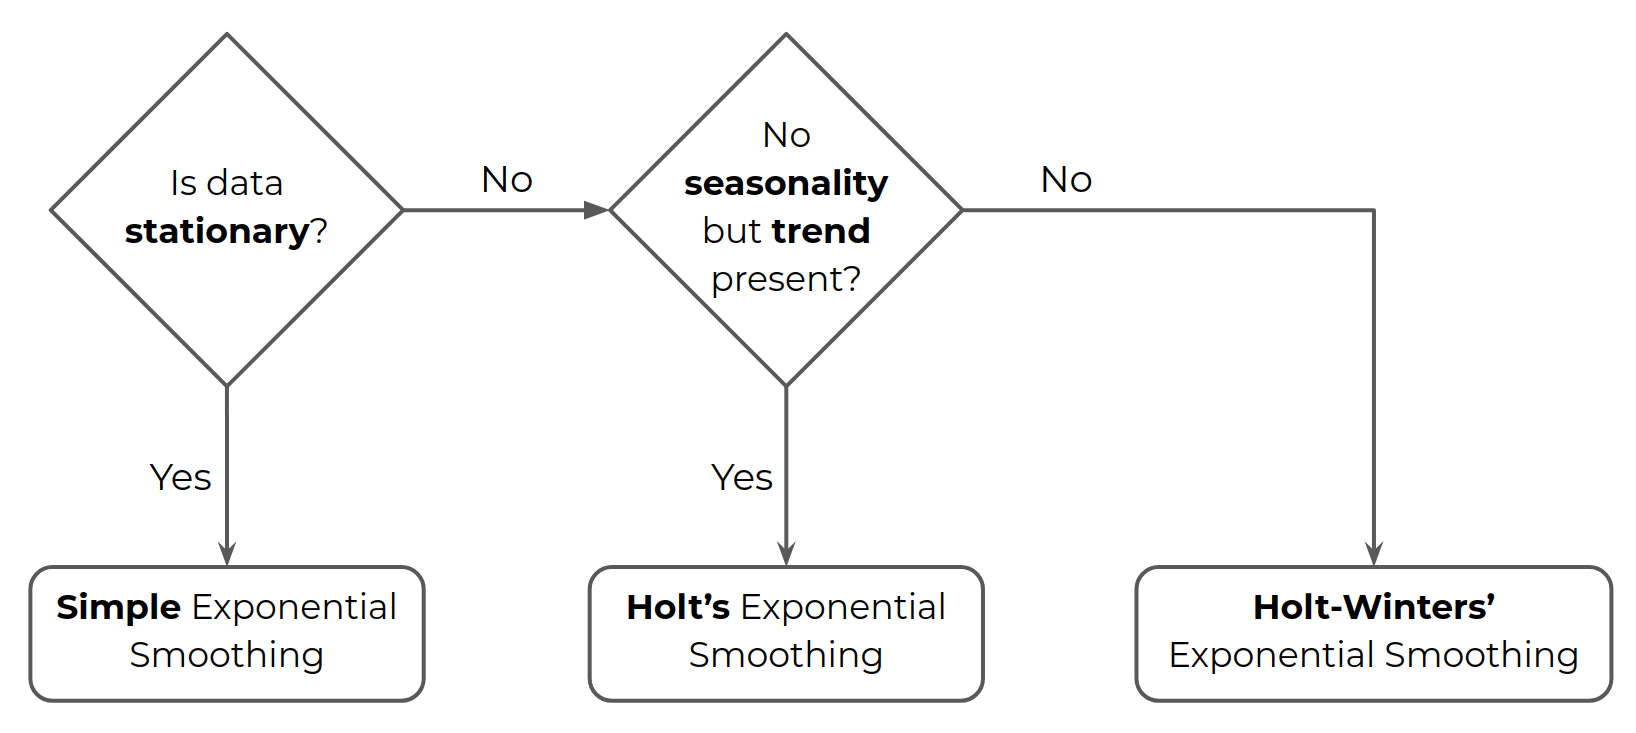</p>

Figure 2: Model Selection 
</center>





## 2. Introduction to Simple Exponential Smoothing

Simple Exponential Smoothing is the simplest among the exponential smoothing methods we'll study in this unit. This method can handle stationary data (without trend and seasonality) only. Let's first introduce the notion of a level. **Level** at time $t$, represented by $l_t$, is the value by exponentially smoothing all the observations till time $t$. It can also be interpreted as the model's prediction at time $t$ and afterwards. And, all the forecasts are equal to the last level for this method. Similarly, we need a parameter $\alpha$ such that $0< \alpha < 1$. This parameter is called the smoothing parameter. Next, let's define SES mathematically.


### Mathematical Expression
>$$
\begin{align*}
\text{Forecasting Equation:} && \hat{X}_{t + h | t} & = l_t, & h = 1, 2, 3, ... 
\\
\\
\text{Level Equation:} && l_t &= \alpha x_t + (1 - \alpha) l_{t - 1}
\end{align*}
$$


The forecasting equation shows that the predictions at times $t + h, \quad h = 1, 2, 3, ...$ are the same and equal to the smoothed value at time $t$. However, for $t + h \le T$, the best prediction is the level just one timestamp previous. The future forecasts are the same and equal to the last level $l_T$. This type of forecast is often called flat forecast.

$$\hat{X}_{T + h | T} = l_T, \quad h = 1, 2, 3, ...$$

The level equation shows that the level at time $t$ weighes the observed value at time t $x_t$ by $\alpha$ and the level at time $t-1$ $l_{t-1}$ by $(1- \alpha)$. In other words, the model remembers $\alpha$ part of current information and $(1 - \alpha)$ part of prior information, the model has collected. This equation is the mainspring of exponential smoothing. We can expand this equation further by replacing $l_{t-1}$ and other levels by their expanded forms as follows:

$$
\begin{align*}
l_t &= \alpha x_t + (1 - \alpha) l_{t - 1} \\
&= \alpha x_t + (1 - \alpha) (\alpha x_{t-1} + (1 - \alpha) l_{t - 2}) \\
&= \alpha x_t + \alpha (1 - \alpha)  x_{t-1} + (1 - \alpha)^2 l_{t - 2} \\
&= \alpha x_t + \alpha (1 - \alpha)  x_{t-1} + (1 - \alpha)^2 (\alpha x_{t-2} + (1 - \alpha) l_{t - 3}) \\
&= \alpha x_t + \alpha (1 - \alpha)  x_{t-1} + \alpha (1 - \alpha)^2  x_{t-2} + (1 - \alpha)^3 l_{t - 3} \\
&= \alpha x_t + \alpha (1 - \alpha)  x_{t-1} + \alpha (1 - \alpha)^2  x_{t-2} + \alpha (1 - \alpha)^3 x_{t - 3} + ... +  (1 - \alpha)^T l_0
\end{align*}
$$

where, $l_0$ is the initial level. The last equation shows that the level equation captures the essence of exponential smoothing. 





### Effect of $\alpha$

$\alpha$ impacts the levels. If $\alpha$ is near to $1$, the weights are more on the nearer values and the weights decay very fast for the older values. On the contrast, if $\alpha$ is near to $0$, the weights decay slowly. Figure 3 shows a table of weights for the values at three different values of $\alpha$.
  
<center>


<p>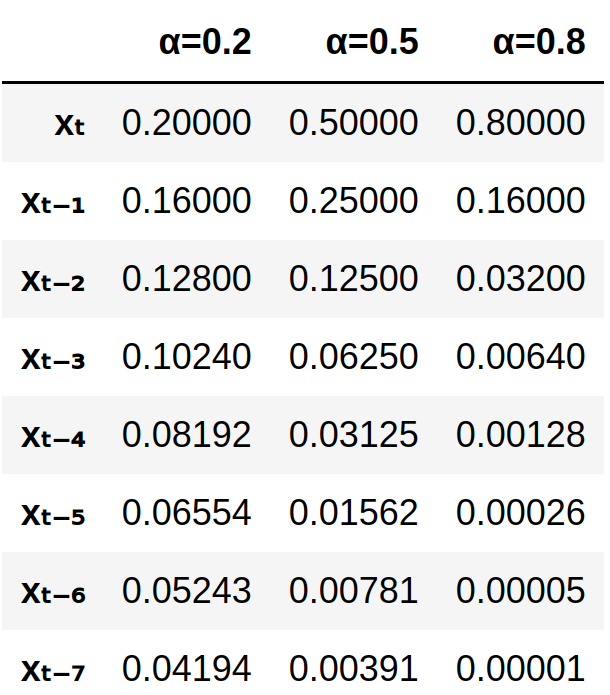</p>

Figure 3: Weights for different $\alpha$ 
</center>



### Model Parameters and Parameters Selection

The simple exponential smoothing method has two parameters:

- Initial level $(l_0)$

- Smoothing parameter $(\alpha)$

We can use the initial observed value $x_0$ as the initial level and an alternative can be to use the mean of the observed data. For the selection of $\alpha$, we usually choose the value which minimizes the sum of squared errors (SSE) between the observed values and the forecasted values (a timestamp ahead prediction).

$$\text{SSE} = \sum_{t = 0} ^T (x_t - \hat{X}_{t | t-1}) ^ 2$$ 





## Key Takeaways

1. The exponential smoothing method models the future forecasts as the weighted average of all the past observations. The weights decay exponentially for the past values; thus, the forecasts are affected more by the immediate past values. 

2. In the simple exponential smoothing model, the level values are the weighted average of all the past observations, and the forecasts are equal to the last level. 
